In [2]:
from statistics import correlation

import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from seaborn import heatmap

# Download latest version
path = kagglehub.dataset_download("dylanjcastillo/7k-books-with-metadata")
print("Path to dataset files:", path)

Path to dataset files: /Users/bhavyashah/.cache/kagglehub/datasets/dylanjcastillo/7k-books-with-metadata/versions/3


In [3]:
books_df = pd.read_csv(f"{path}/books.csv")
books_df

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0
6806,9788185944609,8185944601,Secrets Of The Heart,NaN,Khalil Gibran,Mysticism,http://books.google.com/books/content?id=XcrVp...,NaN,1993.0,4.08,74.0,324.0
6807,9788445074879,8445074873,Fahrenheit 451,NaN,Ray Bradbury,Book burning,NaN,NaN,2004.0,3.98,186.0,5733.0
6808,9789027712059,9027712050,The Berlin Phenomenology,NaN,Georg Wilhelm Friedrich Hegel,History,http://books.google.com/books/content?id=Vy7Sk...,Since the three volume edition ofHegel's Philo...,1981.0,0.00,210.0,0.0


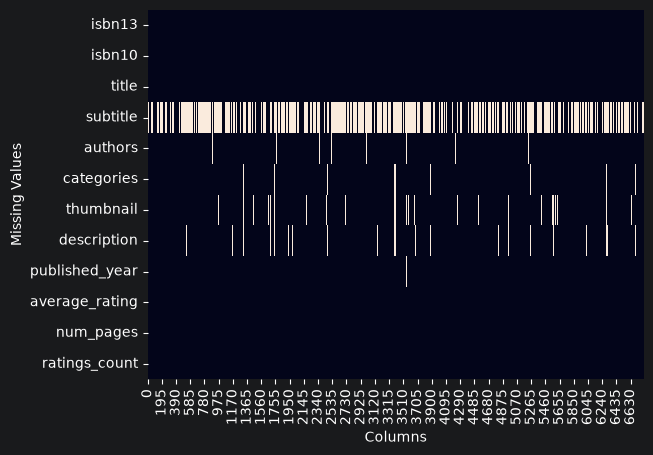

In [9]:
ax = plt.axes()
sns.heatmap(books_df.isna().transpose(), cbar=False, ax=ax)

plt.xlabel('Columns')
plt.ylabel('Missing Values')
plt.show()
# books_df.isna().sum().plot(kind='bar')

#### There is some similarity in the missing values of average rating, num pages and ratings_count, all three are missing together none of them are missing independently

#### Our main areas of concerns is rating and description, where nlp work is mostly headed, so mostly we will remove the books with no description, but we need to check if removing might create some bias-ness in our data
#### So its best to check the correlation between all 4

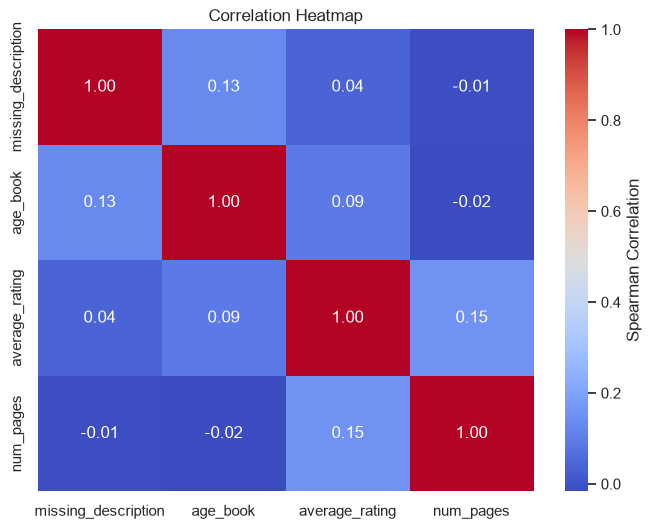

In [4]:
# So firstly corr with missing descrp. books
books_df["missing_description"] = np.where(books_df["description"].isna(), 1, 0)
books_df["age_book"] = 2026 - books_df["published_year"]

ROI_cols = ["missing_description", "age_book", "average_rating", "num_pages"]

correlation_mtrx = books_df[ROI_cols].corr(method = 'spearman')
# Why not pearson?, because when the data is not continuous like 0 and 1, it is preferred to have spearman and when continuous then pearson

sns.set_theme(style="white")
plt.figure(figsize=(8,6))
heatmap = sns.heatmap(correlation_mtrx, annot=True, fmt = ".2f" , cmap="coolwarm", cbar_kws={"label": "Spearman Correlation"})
heatmap.set_title("Correlation Heatmap")
plt.show()

#### From the above Corr. Heatmap, we can see that the books which do not have a description are not biased towards a particular set of books, so we can be rest assured while removing these rows and not have a fear of making our dataset a bit biased

#### Also as we 260 na values for description out of 6810, we can afford removing those
#### Also at the same time it might not be bad to just check how many unique rows in total are there for all these 4 columns being na, as these columns are the most powerful for our recommender

In [21]:
books_df[(books_df["description"].isna()) |
         (books_df["published_year"].isna()) |
         (books_df["average_rating"].isna()) |
         (books_df["num_pages"].isna())
].shape

(303, 14)

In [22]:
(303*100) / 6810

4.4493392070484585

#### 4.4% of the data is not useful to us, so we can remove it

In [5]:
useful_df = books_df[~(books_df["description"].isna()) &
         ~(books_df["published_year"].isna()) &
         ~(books_df["average_rating"].isna()) &
         ~(books_df["num_pages"].isna())]
useful_df.shape

(6507, 14)

#### New Problem is that we have too many distinct categories, we need to group some of them together or we wont have much books in each category for the recommender and also not many are versed with such unique categories

In [6]:
# 531 distinct categories, we need to reduce them somehow
useful_df["categories"].value_counts().reset_index().sort_values("count", ascending=False)

,categories,count
0,Fiction,2523
1,Juvenile Fiction,534
2,Biography & Autobiography,391
3,History,258
4,Literary Criticism,164
...,...,...
280,Brothers and sisters,1
279,"Banks and banking, British",1
278,Rock musicians,1
277,Community life,1


#### Now to do the above we will need to group some categrories to do that we shall use some NLP
#### But before that we shall clean some descriptions too, as very short description dont do justice to the book and will make a bad recommender

In [7]:
useful_df["words_in_description"] = useful_df["description"].str.split().str.len()

In [19]:
# After doing some trials, descrip. lens above 25 seems good descriptions
useful_df.loc[useful_df["words_in_description"].between(25,34), "description"]

9       Kate Blackwell is an enigma and one of the mos...
14      Available in the U.S. for the first time, this...
20      It is 1937, and Charles Ashworth, a Canon to t...
21      Reissue of the author's most famous and well-l...
46      No one believes a little girl when she insists...
                              ...                        
6760    Joel, an English teacher, has never really lik...
6766    Discusses the historical and intellectual back...
6775    Presents nearly one thousand recipes--from app...
6779    Edited by the creator and executive producer o...
6799    This book is the story of a young girl obsesse...
Name: description, Length: 1229, dtype: str

In [54]:
books_df_above_25 = useful_df[useful_df["words_in_description"] >= 25]

In [55]:
books_df_above_25.shape, useful_df.shape

((5197, 15), (6507, 15))

#### We have lost a lot of rows nearly 1300, but description being the main factor of our recommender, we need to be robust with this info

#### Next issue is to handle the subtitle NA's, so the most simple way is to just combine them both if subtitle exists else just use title

In [56]:
books_df_above_25["words_with_subtitle"] = np.where(
    books_df_above_25["subtitle"].isna(),
    books_df_above_25["title"],
    books_df_above_25["title"] + ": " + books_df_above_25["subtitle"]
)

#### Now to make it feasible to create the vector database later on we will aggregae the isbn13 and description, mainly becuase isbn13 is unique for each row

In [58]:
books_df_above_25["description"] = books_df_above_25["isbn13"].astype(str) + " " +books_df_above_25["description"].astype(str)

In [64]:
final_df = books_df_above_25.drop(["subtitle", "missing_description", "age_book", "words_in_description"], axis=1)

In [65]:
final_df

,isbn13,isbn10,title,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,words_with_subtitle
0,9780002005883,0002005883,Gilead,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,9780002005883 A NOVEL THAT READERS and critics...,2004.0,3.85,247.0,361.0,Gilead
1,9780002261982,0002261987,Spider's Web,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,9780002261982 A new 'Christie for Christmas' -...,2000.0,3.83,241.0,5164.0,Spider's Web: A Novel
3,9780006178736,0006178731,Rage of angels,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"9780006178736 A memorable, mesmerizing heroine...",1993.0,3.93,512.0,29532.0,Rage of angels
4,9780006280897,0006280897,The Four Loves,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,9780006280897 Lewis' work on the nature of lov...,2002.0,4.15,170.0,33684.0,The Four Loves
5,9780006280934,0006280935,The Problem of Pain,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"9780006280934 ""In The Problem of Pain, C.S. Le...",2002.0,4.09,176.0,37569.0,The Problem of Pain
...,...,...,...,...,...,...,...,...,...,...,...,...
6802,9788172235222,8172235224,Mistaken Identity,Nayantara Sahgal,Indic fiction (English),http://books.google.com/books/content?id=q-tKP...,9788172235222 On A Train Journey Home To North...,2003.0,2.93,324.0,0.0,Mistaken Identity
6803,9788173031014,8173031010,Journey to the East,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,9788173031014 This book tells the tale of a ma...,2002.0,3.70,175.0,24.0,Journey to the East
6804,9788179921623,817992162X,The Monk Who Sold His Ferrari: A Fable About F...,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,9788179921623 Wisdom to Create a Life of Passi...,2003.0,3.82,198.0,1568.0,The Monk Who Sold His Ferrari: A Fable About F...
6805,9788185300535,8185300534,I Am that,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,9788185300535 This collection of the timeless ...,1999.0,4.51,531.0,104.0,I Am that: Talks with Sri Nisargadatta Maharaj


In [66]:
final_df.to_csv("cleaned_data.csv", index=False)